# Cross-Sections

A **cross-section** bundles everything that describes a waveguide (or wire) profile
into a single reusable object:

| Field | Meaning |
|---|---|
| `width` | Core width (must be even in DBU so geometry stays symmetric) |
| `layer` | Primary / core layer |
| `sections` | Extra layers drawn around the core (cladding, slab, keep-out, …) |
| `radius` | *Hint* for the router: preferred bend radius (not enforced) |
| `radius_min` | *Hint* for the router: minimum allowed bend radius (DRC) |
| `bbox_layers` / `bbox_offsets` | Bounding-box expansion layers (floorplan, die outline) |

Cross-sections are stored in the `KCLayout` registry so any part of a design
can look one up by name.  Routers and schematic-driven design both use cross-section
names to parameterize routing.

## Relation to `LayerEnclosure`

Under the hood a cross-section wraps a `LayerEnclosure`.  The enclosure defines all
the `sections`; the cross-section adds the core `width` and routing hints.
See [Layer Enclosures](layer_enclosure.py) for the enclosure details.

## Three cross-section classes

| Class | Units | Typical use |
|---|---|---|
| `SymmetricalCrossSection` | DBU | Immutable data model — the canonical form stored in `KCLayout` |
| `CrossSection` | DBU | View of a `SymmetricalCrossSection` bound to a `KCLayout` |
| `DCrossSection` | µm | Human-friendly µm variant — converts to DBU internally |

## Setup

In [1]:
import kfactory as kf
from kfactory.cross_section import SymmetricalCrossSection


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Building a cross-section with `DCrossSection` (µm)

`DCrossSection` is the easiest starting point — all dimensions in µm.

```
  ◄──── 3 µm ────►    WGCLAD (cladding)
    ◄── 0.5 µm ──►    WG     (core)

  ┌───────────────┐
  │   WGCLAD      │
  │  ┌─────────┐  │
  │  │   WG    │  │
  │  └─────────┘  │
  │               │
  └───────────────┘
```

The `sections` list entries have the form `(layer, d_max)` or
`(layer, d_min, d_max)` — the distance(s) from the **edge of the core**:

In [2]:
# DCrossSection — all dimensions in µm
xs_wg = kf.DCrossSection(
    kcl=kf.kcl,
    width=0.5,  # core width µm
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),  # cladding: 0 → 2 µm from core edge (symmetric)
    ],
    radius=10.0,  # preferred bend radius hint
    radius_min=5.0,  # minimum bend radius hint (DRC)
    name="WG_500",
)

print(f"name:        {xs_wg.name}")
print(f"width (µm):  {xs_wg.width}")
print(f"layer:       {xs_wg.layer}")
print(f"radius (µm): {xs_wg.radius}")
print(f"sections:    {xs_wg.sections}")

name:        WG_500
width (µm):  0.5
layer:       WG (1/0)
radius (µm): 10.0
sections:    {WGCLAD (2/0): [(None, 2.0)]}


## 2 · Storing in `KCLayout` and looking up by name

Call `kf.kcl.get_icross_section()` (DBU view) or `kf.kcl.get_dcross_section()` (µm view)
to register a cross-section.  On first call with a new spec it is stored; subsequent
calls with the same name return the cached version.

In [3]:
# Register — this returns a CrossSection (DBU view) bound to kf.kcl
xs_dbu: kf.CrossSection = kf.kcl.get_icross_section(xs_wg)

# Retrieve by name later — handy in factory functions that only know the name
xs_retrieved: kf.CrossSection = kf.kcl.get_icross_section("WG_500")

print(f"same object? {xs_dbu.base == xs_retrieved.base}")
print(f"width (DBU): {xs_dbu.width}")  # 500 DBU at 1 nm/DBU

same object? True
width (DBU): 500


## 3 · DBU variant with `CrossSection`

Use `CrossSection` when you want full control at the database-unit level.
All dimensions are integers (database units).

In [4]:
# CrossSection — dimensions in DBU (1 DBU = 1 nm by default)
xs_dbu_direct = kf.CrossSection(
    kcl=kf.kcl,
    width=500,  # 500 DBU = 0.5 µm
    layer=L.WG,
    sections=[
        (L.WGCLAD, 0, 2_000),  # (layer, d_min, d_max) in DBU
    ],
    radius=10_000,  # 10 µm in DBU
    name="WG_500_dbu",
)

print(f"width (DBU): {xs_dbu_direct.width}")
print(f"width (µm):  {kf.kcl.to_um(xs_dbu_direct.width)}")

width (DBU): 500
width (µm):  0.5


## 4 · `SymmetricalCrossSection` — the canonical data model

Both `CrossSection` and `DCrossSection` wrap a `SymmetricalCrossSection`, which is
the immutable Pydantic model that gets stored in `KCLayout.cross_sections`.
You can build one directly using an existing `LayerEnclosure`:

In [5]:
enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(
        name="WG_RIB",
        main_layer=L.WG,
        sections=[
            (L.WGCLAD, 0, 2_000),
            (L.SLAB, 0, 5_000),
        ],
    )
)

xs_base = SymmetricalCrossSection(
    width=700,  # 700 DBU = 0.7 µm
    enclosure=enc,
    name="WG_700_RIB",
    radius=15_000,
    radius_min=8_000,
)

xs_rib: kf.CrossSection = kf.kcl.get_icross_section(xs_base)
print(f"layers:  {list(xs_rib.sections.keys())}")
print(f"radius:  {kf.kcl.to_um(xs_rib.radius)} µm")

layers:  [SLAB (3/0), WGCLAD (2/0)]
radius:  15.0 µm


## 5 · Multi-layer and annular sections

Three-element section tuples `(layer, d_min, d_max)` produce **annular** (ring-shaped)
regions — useful for doping implants or etch-stop layers that must not touch the core
edge.

In [6]:
xs_implant = kf.DCrossSection(
    kcl=kf.kcl,
    width=0.5,
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),  # cladding: extends 0–2 µm from core
        (L.SLAB, 0.5, 3.0),  # slab ring: starts 0.5 µm, ends 3 µm from core
    ],
    name="WG_IMPLANT",
)

for layer, segs in xs_implant.sections.items():
    for d_min, d_max in segs:
        print(f"  {layer}  {d_min} → {d_max} µm")

  SLAB (3/0)  0.5 → 3.0 µm
  WGCLAD (2/0)  None → 2.0 µm


## 6 · Bounding-box expansion layers

`bbox_layers` / `bbox_offsets` add layers that expand the component bounding box by a
fixed amount — commonly used for die outline, exclusion zones, or floorplan tiles.
These do NOT use Minkowski operations; they simply offset the bounding box polygon.

In [7]:
xs_with_fp = kf.DCrossSection(
    kcl=kf.kcl,
    width=0.5,
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),
    ],
    bbox_layers=[L.FLOORPLAN],
    bbox_offsets=[5.0],  # floorplan 5 µm outside bounding box
    name="WG_FP",
)

xs_fp_dbu = kf.kcl.get_icross_section(xs_with_fp)
print(f"bbox_sections: {xs_fp_dbu.bbox_sections}")

bbox_sections: {FLOORPLAN (10/0): 5000}


## 7 · Creating ports with a cross-section

A `Port` stores its geometry via its `cross_section`; you can pass a
`SymmetricalCrossSection` directly to `add_port`.
Because `@kf.cell` caches by parameters, factory functions should accept
the cross-section **name** (a string) and look it up inside:

port o1 width: 500 DBU = 0.5 µm
port o1 layer: WG


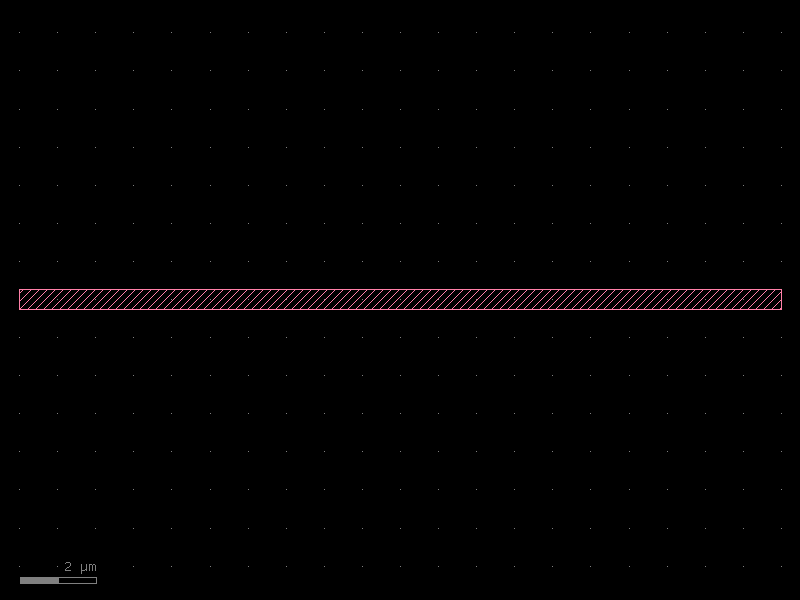

In [8]:
@kf.cell
def mzi_arm(cross_section: str, length_um: float = 20.0) -> kf.KCell:
    """A simple straight acting as an MZI arm.

    Args:
        cross_section: Name of a registered cross-section.
        length_um: Arm length in µm.
    """
    c = kf.KCell()
    xs = kf.kcl.get_icross_section(cross_section)
    length = kf.kcl.to_dbu(length_um)
    w = xs.width

    c.shapes(kf.kcl.find_layer(xs.layer)).insert(
        kf.kdb.Box(-length // 2, -w // 2, length // 2, w // 2)
    )

    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, -length // 2, 0),  # West-facing
            cross_section=xs.base,
            kcl=kf.kcl,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, length // 2, 0),  # East-facing
            cross_section=xs.base,
            kcl=kf.kcl,
        )
    )
    return c


arm = mzi_arm(cross_section="WG_500")
print(f"port o1 width: {arm['o1'].width} DBU = {kf.kcl.to_um(arm['o1'].width)} µm")
print(f"port o1 layer: {arm['o1'].layer}")
arm.plot()

## 8 · Cross-sections in routing

Optical and electrical routers accept a `cross_section` argument on start/end ports —
the router reads `xs.radius` and `xs.radius_min` to choose bend radii automatically.

The typical workflow:

1. Define one `DCrossSection` per waveguide type at PDK setup time.
2. Register it on `kf.kcl` with a human-readable name.
3. Pass the name (or the `CrossSection` object) wherever routers need a waveguide spec.

```python
# PDK setup (once)
xs_wg = kf.DCrossSection(kcl=kf.kcl, width=0.5, layer=L.WG,
                         sections=[(L.WGCLAD, 2.0)], radius=10.0, name="WG_500")
kf.kcl.get_icross_section(xs_wg)   # register

# In a factory function — look up by name
def my_bend(cross_section: str = "WG_500") -> kf.KCell:
    xs = kf.kcl.get_icross_section(cross_section)
    ...
```

See [Routing Overview](../routing/overview.py) for full routing examples.

## Summary

| Need | Use |
|---|---|
| Human-friendly µm API | `kf.DCrossSection(kcl, width, layer, sections, ...)` |
| DBU integer precision | `kf.CrossSection(kcl, width, layer, sections, ...)` |
| Reuse an existing enclosure | `SymmetricalCrossSection(width, enclosure)` |
| Register / look up by name | `kf.kcl.get_icross_section(name_or_spec)` |
| µm view of a registered xs | `kf.kcl.get_dcross_section(name_or_spec)` |

## See Also

| Topic | Where |
|-------|-------|
| Layer enclosures (auto-cladding) | [Enclosures: Layer Enclosure](layer_enclosure.py) |
| Cell-level enclosures (tiling) | [Enclosures: KCell Enclosure](kcell_enclosure.py) |
| Straight waveguide (uses xs) | [Components: Straight](cells/factories/straight.py) |
| Width tapers (uses xs) | [Components: Tapers](cells/factories/taper.py) |
| Routing with cross-sections | [Routing: Overview](../routing/overview.py) |